
Number of bits :  4

User input basis state to circuit :  1001


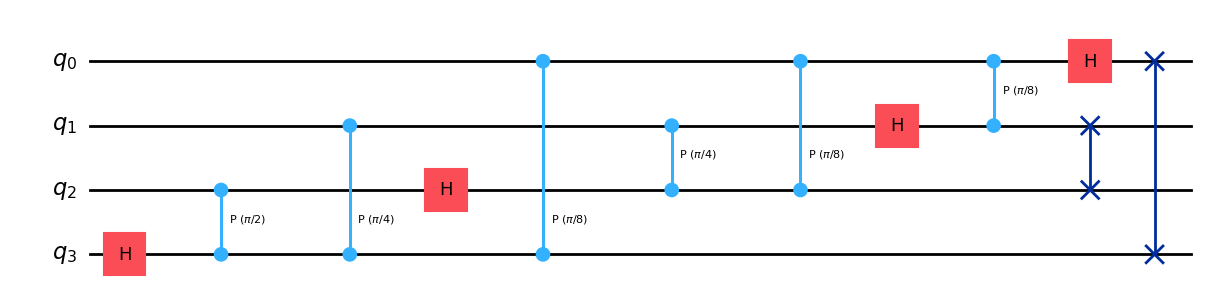


Initial Statevector:


<IPython.core.display.Latex object>


Final Statevector:


<IPython.core.display.Latex object>

In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random
import numpy as np 

bits_no = int(input("Enter the number of bits"))
secret_string = list(str(input("Enter your basis state in 0s and 1s")))

print("\nNumber of bits : ", bits_no)
print("\nUser input basis state to circuit : ", ''.join(secret_string))

N = 2**bits_no

# Building the Circuit.

q_reg = QuantumRegister(bits_no, "q")
circuit_1 = QuantumCircuit(q_reg)

for i in range(bits_no):
    p = bits_no - i - 1
    circuit_1.h(q_reg[p])
    for j in range(p):
        circuit_1.cp(2*pi/(2**(bits_no - p + j + 1)),q_reg[p - j - 1],q_reg[p])

# Final SWAP part
for i in range(bits_no // 2):
    circuit_1.swap(q_reg[i], q_reg[bits_no - i - 1])

# Initialize user input as initial statevector
initial_state = Statevector.from_label(''.join(secret_string))

display(circuit_1.draw(output="mpl"))

print("\nInitial Statevector:")
display(initial_state.draw("latex"))

# Evolve statevector through circuit
final_state = initial_state.evolve(circuit_1)

print("\nFinal Statevector:")
display(final_state.draw("latex"))
